In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings  
warnings.filterwarnings('ignore') 
import shap

In [2]:


TARGET = "HadHeartAttack"
train_df = pd.read_csv("train_scaled_smote.csv")
validation_df = pd.read_csv("validation_scaled.csv")
test_df = pd.read_csv("test_scaled.csv")

print("=" * 70)
print("DATASETS LOADED SUCCESSFULLY")
print("=" * 70)

print("Training Shape   :", train_df.shape)
print("Validation Shape :", validation_df.shape)
print("Test Shape       :", test_df.shape)

# ============================================================
# SPLIT FEATURES AND TARGET
# ============================================================

X_train = train_df.drop(columns=[TARGET]).copy()
y_train = train_df[TARGET].copy()

X_val = validation_df.drop(columns=[TARGET]).copy()
y_val = validation_df[TARGET].copy()

X_test = test_df.drop(columns=[TARGET]).copy()
y_test = test_df[TARGET].copy()

# ============================================================
# TARGET ENCODING
# Handles:
# 0 / 1
# Yes / No
# YES / NO
# ============================================================

def encode_target(y):

    y = pd.Series(y).copy()

    # Already numeric
    if pd.api.types.is_numeric_dtype(y):
        return y.astype(np.int32)

    # Convert string labels
    y = (
        y.astype(str)
         .str.strip()
         .str.upper()
    )

    y = y.replace({
        "NO": 0,
        "YES": 1
    })

    # Convert to integer
    y = pd.to_numeric(y, errors="raise")

    return y.astype(np.int32)

# Encode targets
y_train = encode_target(y_train)
y_val = encode_target(y_val)
y_test = encode_target(y_test)

# ============================================================
# CONVERT FEATURES TO FLOAT32
# ============================================================

X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)

# ============================================================
# INPUT DIMENSION
# ============================================================

INPUT_DIM = X_train.shape[1]

# ============================================================
# VERIFY TARGETS
# ============================================================

print("\nUnique Labels")
print("-" * 40)

print("Train :", np.unique(y_train))
print("Val   :", np.unique(y_val))
print("Test  :", np.unique(y_test))

assert set(np.unique(y_train)).issubset({0, 1})
assert set(np.unique(y_val)).issubset({0, 1})
assert set(np.unique(y_test)).issubset({0, 1})

# ============================================================
# CHECK FOR MISSING VALUES
# ============================================================

print("\nMissing Values")
print("-" * 40)

print("Train :", X_train.isnull().sum().sum())
print("Val   :", X_val.isnull().sum().sum())
print("Test  :", X_test.isnull().sum().sum())

# ============================================================
# CLASS DISTRIBUTION
# ============================================================

print("\nTraining Distribution")
print("-" * 40)
print(y_train.value_counts())

print("\nValidation Distribution")
print("-" * 40)
print(y_val.value_counts())

print("\nTest Distribution")
print("-" * 40)
print(y_test.value_counts())

# ============================================================
# FEATURE INFORMATION
# ============================================================

print("\nNumber of Features :", INPUT_DIM)

print("\nFirst 10 Features")
print("-" * 40)
print(list(X_train.columns[:10]))

# ============================================================
# DATA SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("DATA SUMMARY")
print("=" * 70)

print(f"Training Samples   : {len(X_train):,}")
print(f"Validation Samples : {len(X_val):,}")
print(f"Test Samples       : {len(X_test):,}")

print(f"\nInput Features     : {INPUT_DIM}")

print("\nTarget Variable :", TARGET)

print("\n✓ Target labels verified")
print("✓ Features converted to float32")
print("✓ Training data loaded")
print("✓ Validation data loaded")
print("✓ Test data loaded")

print("=" * 70)
print("CELL 1 COMPLETED SUCCESSFULLY")
print("=" * 70)

DATASETS LOADED SUCCESSFULLY
Training Shape   : (622452, 32)
Validation Shape : (41243, 32)
Test Shape       : (41243, 32)

Unique Labels
----------------------------------------
Train : [0 1]
Val   : [0 1]
Test  : [0 1]

Missing Values
----------------------------------------
Train : 0
Val   : 0
Test  : 0

Training Distribution
----------------------------------------
HadHeartAttack
0    311226
1    311226
Name: count, dtype: int64

Validation Distribution
----------------------------------------
HadHeartAttack
0    38903
1     2340
Name: count, dtype: int64

Test Distribution
----------------------------------------
HadHeartAttack
0    38903
1     2340
Name: count, dtype: int64

Number of Features : 31

First 10 Features
----------------------------------------
['Sex', 'GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays', 'LastCheckupTime', 'PhysicalActivity', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadOtherCancer']

DATA SUMMARY
Training Samples   : 622,452
Validation Sampl

In [3]:
import pandas as pd
import numpy as np

TARGET = "HadHeartAttack"

test_df = pd.read_csv("test_data.csv")

X_test_original = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

In [4]:
y_test = (
    y_test.astype(str)
          .str.strip()
          .str.upper()
          .replace({
              "NO": 0,
              "YES": 1
          })
          .astype(int)
)

In [5]:
sex_test = X_test_original["Sex"]

age_test = X_test_original["AgeGroup"]

bmi_test = X_test_original["BMICategory"]
smoking_test = X_test_original["SmokingStatus"]

health_test = X_test_original["GeneralHealth"]

In [6]:
scaled_test = pd.read_csv("test_scaled.csv")

X_test_model = scaled_test.drop(
    columns=[TARGET]
).astype(np.float32)

In [7]:
from tensorflow.keras.models import load_model

MODEL_NAMES = [
    "FNN",
    "Wide_Deep",
    "Residual",
    "Attention"
]

trained_models = {}

for model_name in MODEL_NAMES:

    trained_models[model_name] = load_model(
        f"saved_models/{model_name}.keras"
    )

In [8]:
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score
)

def subgroup_metrics(
    y_true,
    y_pred,
    y_prob,
    subgroup
):

    results = []

    for group in sorted(
        pd.Series(subgroup)
        .dropna()
        .unique()
    ):

        mask = subgroup == group

        if mask.sum() < 20:
            continue

        results.append({

            "Group": group,

            "N": mask.sum(),

            "Sensitivity":
                recall_score(
                    y_true[mask],
                    y_pred[mask]
                ),

            "PPV":
                precision_score(
                    y_true[mask],
                    y_pred[mask],
                    zero_division=0
                ),

            "F1":
                f1_score(
                    y_true[mask],
                    y_pred[mask]
                ),

            "ROC_AUC":
                roc_auc_score(
                    y_true[mask],
                    y_prob[mask]
                )
        })

    return pd.DataFrame(results)

In [9]:
model = trained_models["Residual"]

threshold = 0.45

y_prob = model.predict(
    X_test_model,
    verbose=0
).flatten()

y_pred = (
    y_prob >= threshold
).astype(int)

sex_results = subgroup_metrics(
    y_test,
    y_pred,
    y_prob,
    sex_test
)

print(sex_results)

    Group      N  Sensitivity       PPV        F1   ROC_AUC
0  Female  21874     0.845198  0.092896  0.167394  0.829731
1    Male  19369     0.946392  0.135225  0.236639  0.833260


In [10]:
for v in dir():
    if "fair" in v.lower():
        print(v)

In [11]:
import joblib

best_threshold = joblib.load(
    "best_threshold.pkl"
)
print(best_threshold)

0.43


In [12]:
MODEL_NAMES
trained_models
best_threshold
X_test_model
y_test
X_test_original

,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivity,HadStroke,HadAsthma,HadSkinCancer,HadOtherCancer,...,EverHadPneumoniaVax,ReceivedFluVax,EverTestedHIV,EverHadCOVID,AgeGroup,HighBloodPressureRisk,CholesterolChecked,BMICategory,SmokingStatus,DrinksPerDay
0,Male,Very good,5.0,NaN,Within past year,Yes,No,No,No,No,...,No,Yes,No,Yes,65-69,No,Yes,Normal,Never smoked,29.0
1,Female,Good,NaN,NaN,Within past year,No,No,No,No,No,...,Yes,Yes,No,No,75-79,No,Yes,Obese,Never smoked,0.0
2,Female,Excellent,NaN,NaN,NaN,Yes,No,No,No,No,...,NaN,Yes,No,Yes,25-29,Yes,Never had cholesterol checked,Normal,Never smoked,NaN
3,Female,Excellent,NaN,30.0,Within past year,Yes,No,No,No,No,...,No,No,No,No,25-29,Yes,Yes,Normal,Never smoked,3.0
4,Female,Excellent,2.0,2.0,Within past year,Yes,No,No,No,No,...,No,No,Yes,No,50-54,Yes,Yes,Normal,Former smoker,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41238,Female,Very good,NaN,NaN,Within past year,No,No,No,No,No,...,No,No,NaN,No,80+,No,Yes,Normal,Former smoker,43.0
41239,Female,Very good,NaN,4.0,Within past year,Yes,No,No,No,No,...,Yes,Yes,Yes,No,35-39,Yes,Yes,Overweight,Never smoked,27.0
41240,Female,Poor,15.0,20.0,Within past year,Yes,No,No,No,No,...,No,No,Yes,Yes,40-44,Yes,NaN,Obese,Current smoker - daily,0.0
41241,Female,Poor,30.0,NaN,Within past year,Yes,No,No,Yes,Yes,...,No,Yes,No,No,70-74,No,Yes,Normal,Former smoker,3.0


In [13]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def fairness_assessment(
    models,
    model_names,
    X_test_model,
    X_test_original,
    y_test,
    sensitive_features,
    thresholds=None
):

    results = []

    y_test = np.asarray(y_test)

    for model_name, model in zip(model_names, models):

        # predictions
        y_prob = model.predict(X_test_model).ravel()

        if thresholds is not None:
            threshold = thresholds.get(model_name, 0.5)
        else:
            threshold = 0.5

        y_pred = (y_prob >= threshold).astype(int)

        for feature in sensitive_features:

            if feature not in X_test_original.columns:
                print(f"{feature} not found")
                continue

            for group in X_test_original[feature].dropna().unique():

                mask = X_test_original[feature] == group

                if mask.sum() < 30:
                    continue

                y_true_g = y_test[mask]
                y_pred_g = y_pred[mask]
                y_prob_g = y_prob[mask]

                tn, fp, fn, tp = confusion_matrix(
                    y_true_g,
                    y_pred_g,
                    labels=[0, 1]
                ).ravel()

                sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
                specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
                ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan

                try:
                    auc = roc_auc_score(
                        y_true_g,
                        y_prob_g
                    )
                except:
                    auc = np.nan

                results.append({
                    "Model": model_name,
                    "Variable": feature,
                    "Group": group,
                    "Count": mask.sum(),
                    "Sensitivity": sensitivity,
                    "Specificity": specificity,
                    "PPV": ppv,
                    "F1": f1_score(
                        y_true_g,
                        y_pred_g,
                        zero_division=0
                    ),
                    "ROC_AUC": auc
                })

    return pd.DataFrame(results)

In [14]:
sensitive_features = [
    "Sex",
    "AgeGroup",
    "BMICategory",
    "SmokingStatus",
    "GeneralHealth"
]
fairness_results = fairness_assessment(
    models=list(trained_models.values()),
    model_names=list(trained_models.keys()),
    X_test_model=X_test_model,
    X_test_original=X_test_original,
    y_test=y_test,
    sensitive_features=sensitive_features,
    thresholds=None
)

1289/1289 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


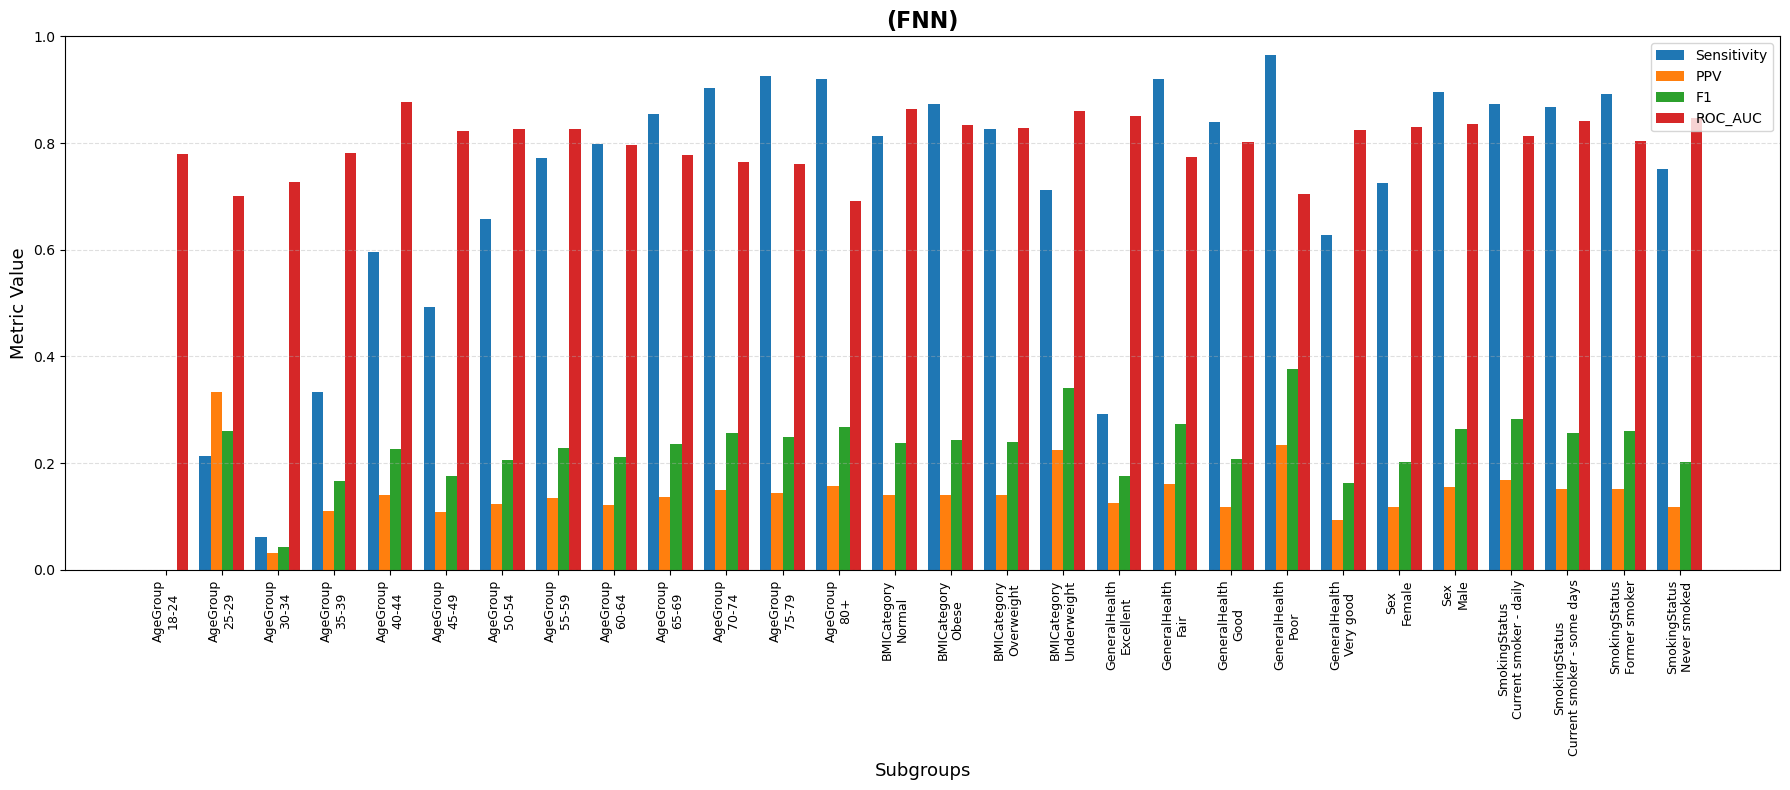

Saved: fairness_figures/FNN_publication_fairness.png


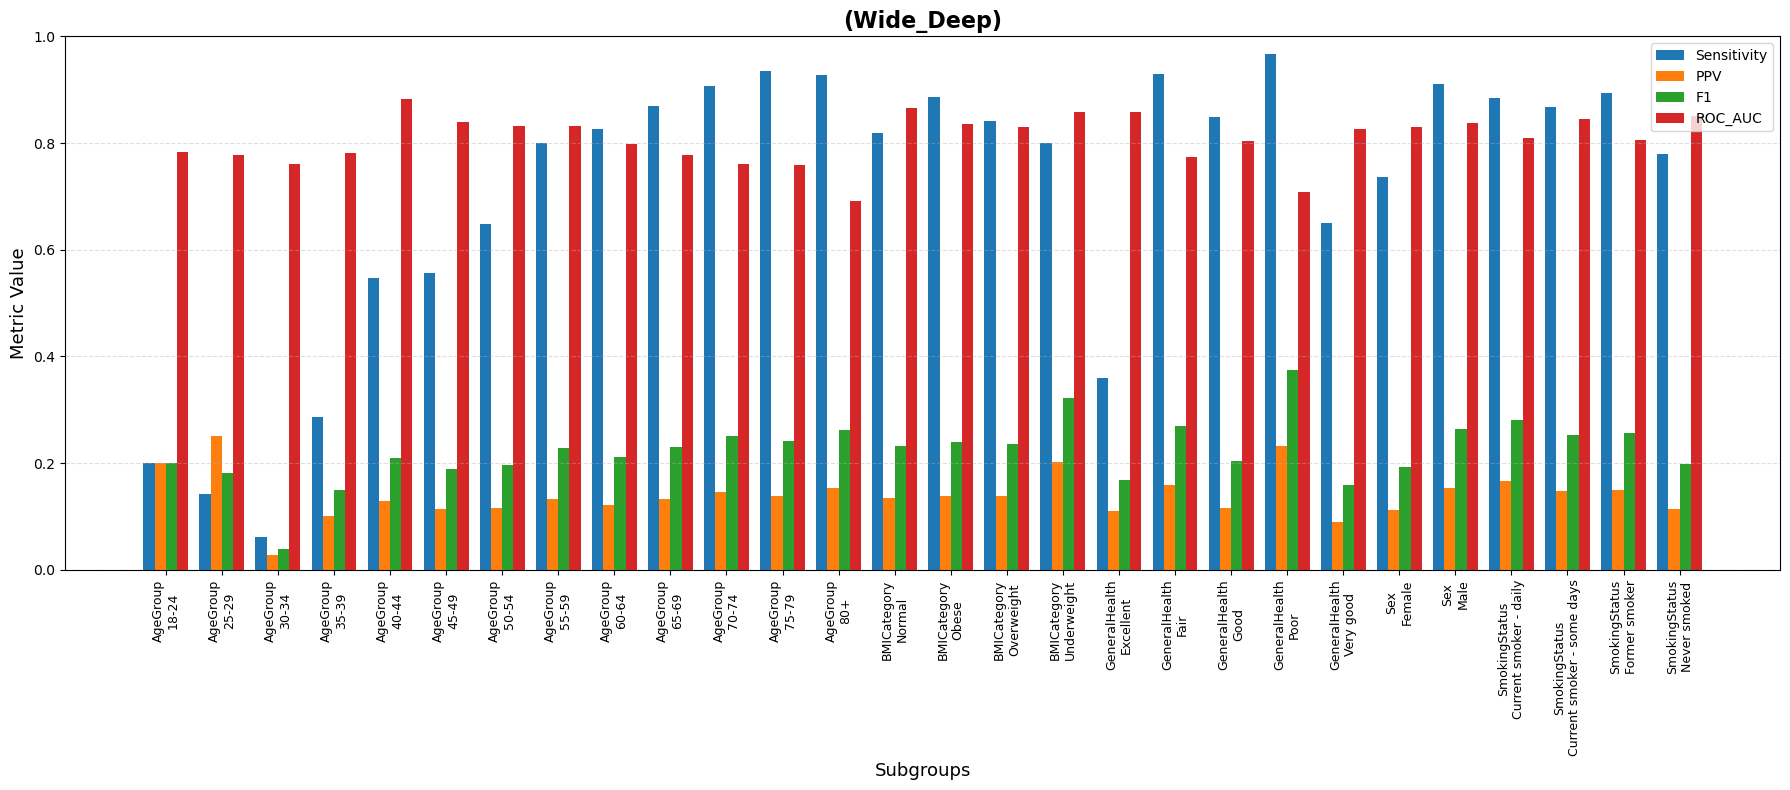

Saved: fairness_figures/Wide_Deep_publication_fairness.png


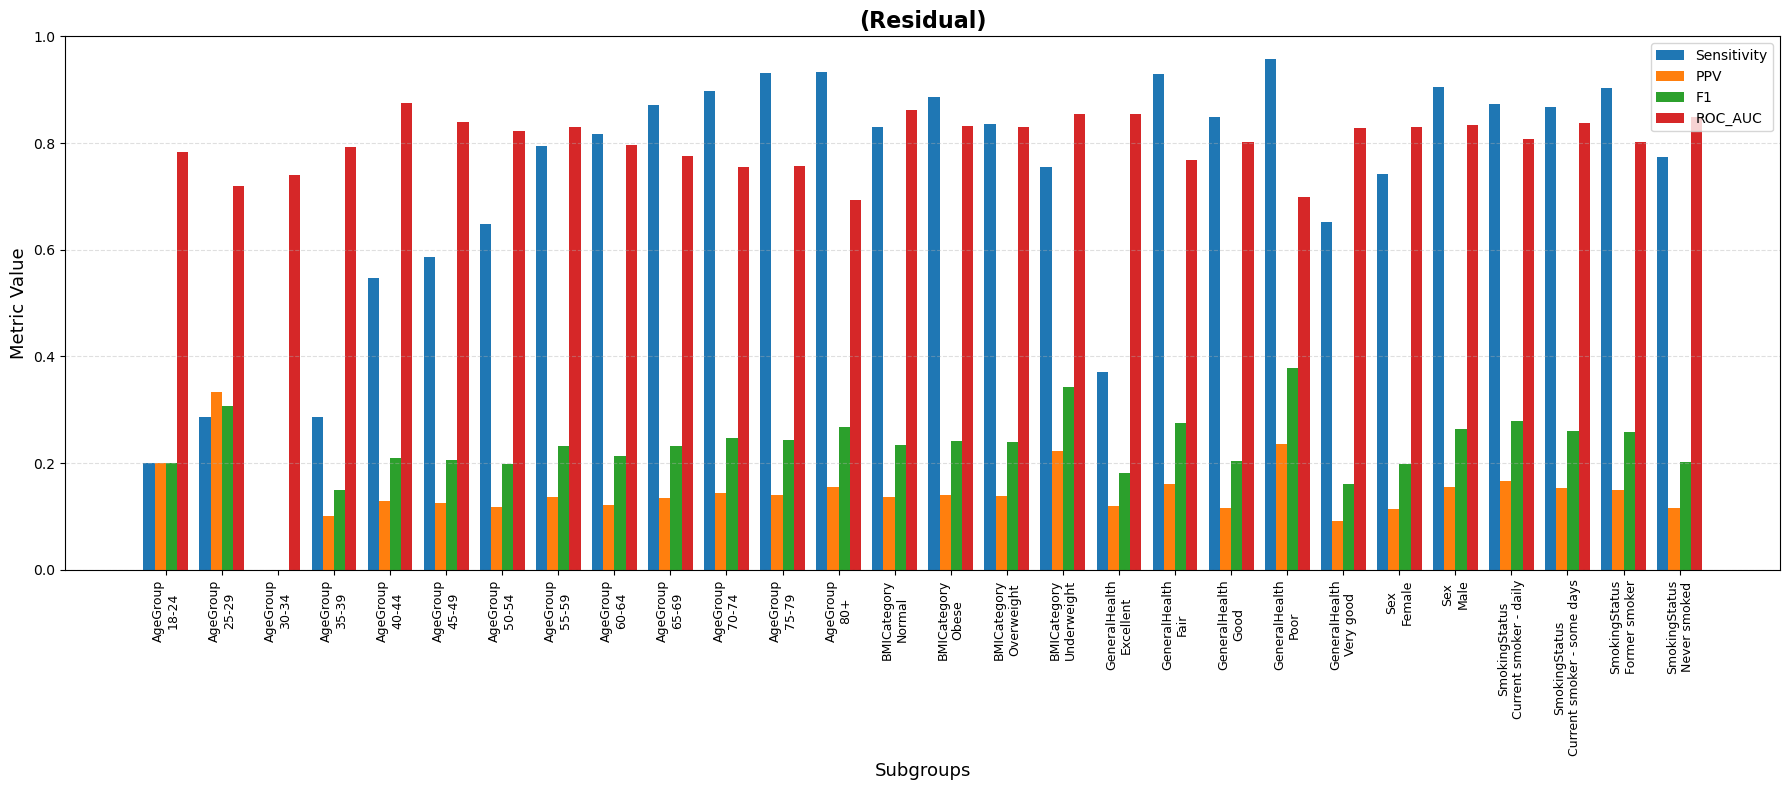

Saved: fairness_figures/Residual_publication_fairness.png


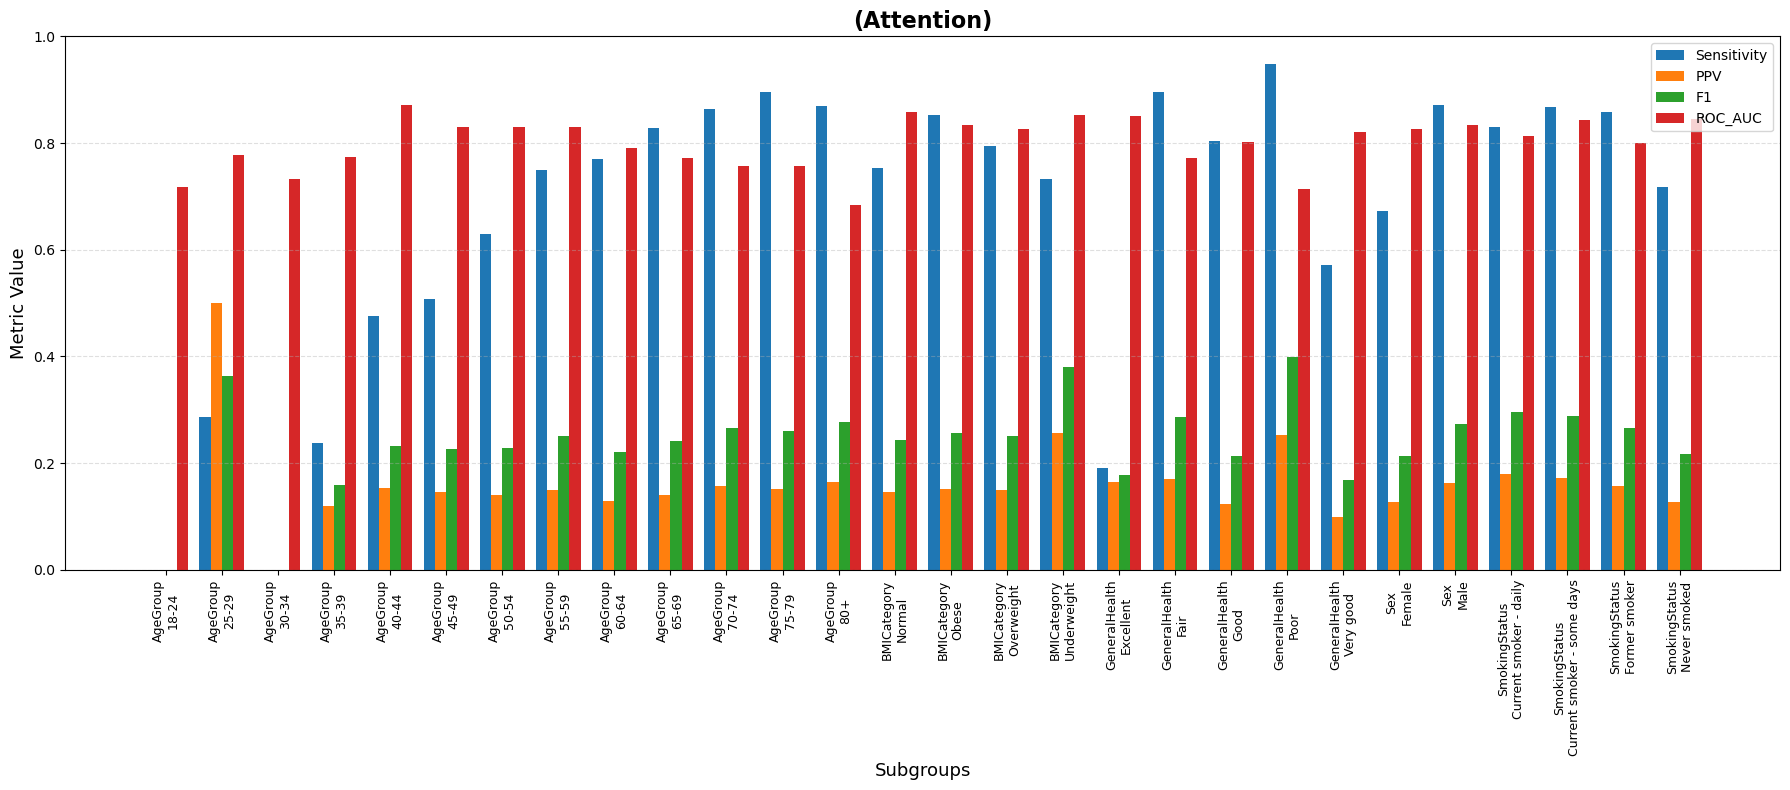

Saved: fairness_figures/Attention_publication_fairness.png


In [15]:


import os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("fairness_figures", exist_ok=True)

DL_MODELS = [
    "FNN",
    "Wide_Deep",
    "Residual",
    "Attention"
]

METRICS = [
    "Sensitivity",
    "PPV",
    "F1",
    "ROC_AUC"
]

for model_name in DL_MODELS:

    plot_df = fairness_results[
        fairness_results["Model"] == model_name
    ].copy()

    if plot_df.empty:
        print(f"No data for {model_name}")
        continue

    plot_df["Label"] = (
        plot_df["Variable"].astype(str)
        + "\n"
        + plot_df["Group"].astype(str)
    )

    plot_df = plot_df.sort_values(
        ["Variable", "Group"]
    ).reset_index(drop=True)

    n_groups = len(plot_df)

    x = np.arange(n_groups)

    width = 0.20

    fig, ax = plt.subplots(
        figsize=(18, 8)
    )

    for i, metric in enumerate(METRICS):

        ax.bar(
            x + (i - 1.5) * width,
            plot_df[metric],
            width,
            label=metric
        )

    ax.set_title(
        f"({model_name})",
        fontsize=16,
        fontweight="bold"
    )

    
    ax.set_ylabel(
        "Metric Value",
        fontsize=13
    )
    ax.set_xlabel(
        "Subgroups",
        fontsize=13
    )


    ax.set_ylim(0, 1)

    ax.set_xticks(x)

    ax.set_xticklabels(
        plot_df["Label"],
        rotation=90,
        fontsize=9
    )

    ax.legend(
        fontsize=10,
        frameon=True,
        loc="upper right"
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    plt.tight_layout()

    save_path = (
        f"fairness_figures/"
        f"{model_name}_publication_fairness.png"
    )

    plt.savefig(
        save_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    print(f"Saved: {save_path}")

# Fairness Assesement of Classical ML models

In [16]:
import joblib

lr_model = joblib.load(
    "saved_models/Logistic Regression.pkl"
)

knn_model = joblib.load(
    "saved_models/knn.pkl"
)

dt_model = joblib.load(
    "saved_models/Decision Tree.pkl"
)

gb_model = joblib.load(
    "saved_models/Gradient Boosting.pkl"
)

rf_model = joblib.load(
    "saved_models/Random Forest.pkl"
)

In [17]:
ML_MODELS = [
    "Logistic Regression",
    "KNN",
    "Decision Tree",
    "Gradient Boosting",
    "Random Forest"
]

ML_MODEL_OBJECTS = [
    lr_model,
    knn_model,
    dt_model,
    gb_model,
    rf_model
]

In [18]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

def fairness_assessment_ml(
    models,
    model_names,
    X_test_model,
    X_test_original,
    y_test,
    sensitive_features,
    threshold=0.5
):

    results = []

    for model, model_name in zip(models, model_names):

        y_prob = model.predict_proba(X_test_model)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)

        for feature in sensitive_features:

            groups = X_test_original[feature].dropna().unique()

            for group in groups:

                mask = X_test_original[feature] == group

                if mask.sum() < 10:
                    continue

                y_true_g = y_test[mask]
                y_pred_g = y_pred[mask]
                y_prob_g = y_prob[mask]

                tn, fp, fn, tp = confusion_matrix(
                    y_true_g,
                    y_pred_g,
                    labels=[0, 1]
                ).ravel()

                sensitivity = recall_score(
                    y_true_g,
                    y_pred_g,
                    zero_division=0
                )

                specificity = (
                    tn / (tn + fp)
                    if (tn + fp) > 0
                    else np.nan
                )

                ppv = precision_score(
                    y_true_g,
                    y_pred_g,
                    zero_division=0
                )

                npv = (
                    tn / (tn + fn)
                    if (tn + fn) > 0
                    else np.nan
                )

                f1 = f1_score(
                    y_true_g,
                    y_pred_g,
                    zero_division=0
                )

                try:
                    auc = roc_auc_score(
                        y_true_g,
                        y_prob_g
                    )
                except:
                    auc = np.nan

                results.append({
                    "Model": model_name,
                    "Feature": feature,
                    "Group": group,
                    "N": mask.sum(),
                    "Sensitivity": sensitivity,
                    "Specificity": specificity,
                    "PPV": ppv,
                    "NPV": npv,
                    "F1": f1,
                    "ROC_AUC": auc
                })

    return pd.DataFrame(results)

In [19]:
sensitive_features = [
    "Sex",
    "AgeGroup",
    "BMICategory",
    "SmokingStatus",
    "GeneralHealth"
]

ml_fairness_results = fairness_assessment_ml(
    models=ML_MODEL_OBJECTS,
    model_names=ML_MODELS,
    X_test_model=X_test_model,
    X_test_original=X_test_original,
    y_test=y_test,
    sensitive_features=sensitive_features,
    threshold=0.5
)

In [20]:
ml_fairness_results
fairness_results      # DL fairness results

,Model,Variable,Group,Count,Sensitivity,Specificity,PPV,F1,ROC_AUC
0,FNN,Sex,Male,19369,0.896220,0.601764,0.154539,0.263621,0.834850
1,FNN,Sex,Female,21874,0.725424,0.770689,0.117690,0.202524,0.829617
2,FNN,AgeGroup,65-69,4387,0.854651,0.541182,0.136808,0.235860,0.777145
3,FNN,AgeGroup,75-79,3251,0.926346,0.326087,0.143421,0.248386,0.760719
4,FNN,AgeGroup,25-29,1941,0.214286,0.996886,0.333333,0.260870,0.701479
...,...,...,...,...,...,...,...,...,...
107,Attention,GeneralHealth,Very good,13462,0.572222,0.856358,0.098659,0.168301,0.821477
108,Attention,GeneralHealth,Good,13844,0.803549,0.654845,0.123346,0.213864,0.801691
109,Attention,GeneralHealth,Excellent,5654,0.191011,0.984546,0.165049,0.177083,0.849896
110,Attention,GeneralHealth,Fair,6205,0.895501,0.457215,0.170867,0.286977,0.771128


In [21]:
for col in ml_fairness_results.columns:
    print(col)

Model
Feature
Group
N
Sensitivity
Specificity
PPV
NPV
F1
ROC_AUC


In [22]:


print("Shape:")
print(ml_fairness_results.shape)

print("\nColumns:")
print(ml_fairness_results.columns.tolist())

print("\nModels:")
print(
    ml_fairness_results["Model"]
    .unique()
)

ml_fairness_results.head()

Shape:
(140, 10)

Columns:
['Model', 'Feature', 'Group', 'N', 'Sensitivity', 'Specificity', 'PPV', 'NPV', 'F1', 'ROC_AUC']

Models:
['Logistic Regression' 'KNN' 'Decision Tree' 'Gradient Boosting'
 'Random Forest']


,Model,Feature,Group,N,Sensitivity,Specificity,PPV,NPV,F1,ROC_AUC
0,Logistic Regression,Sex,Male,19369,0.850172,0.657865,0.167934,0.981838,0.280467,0.836834
1,Logistic Regression,Sex,Female,21874,0.666667,0.810615,0.129244,0.982957,0.216514,0.828524
2,Logistic Regression,AgeGroup,65-69,4387,0.784884,0.621568,0.150000,0.971395,0.251866,0.772616
3,Logistic Regression,AgeGroup,75-79,3251,0.900850,0.383368,0.151069,0.969459,0.258747,0.759710
4,Logistic Regression,AgeGroup,25-29,1941,0.000000,0.998443,0.000000,0.992776,0.000000,0.692435


In [23]:
display(ml_fairness_results.head())

,Model,Feature,Group,N,Sensitivity,Specificity,PPV,NPV,F1,ROC_AUC
0,Logistic Regression,Sex,Male,19369,0.850172,0.657865,0.167934,0.981838,0.280467,0.836834
1,Logistic Regression,Sex,Female,21874,0.666667,0.810615,0.129244,0.982957,0.216514,0.828524
2,Logistic Regression,AgeGroup,65-69,4387,0.784884,0.621568,0.150000,0.971395,0.251866,0.772616
3,Logistic Regression,AgeGroup,75-79,3251,0.900850,0.383368,0.151069,0.969459,0.258747,0.759710
4,Logistic Regression,AgeGroup,25-29,1941,0.000000,0.998443,0.000000,0.992776,0.000000,0.692435


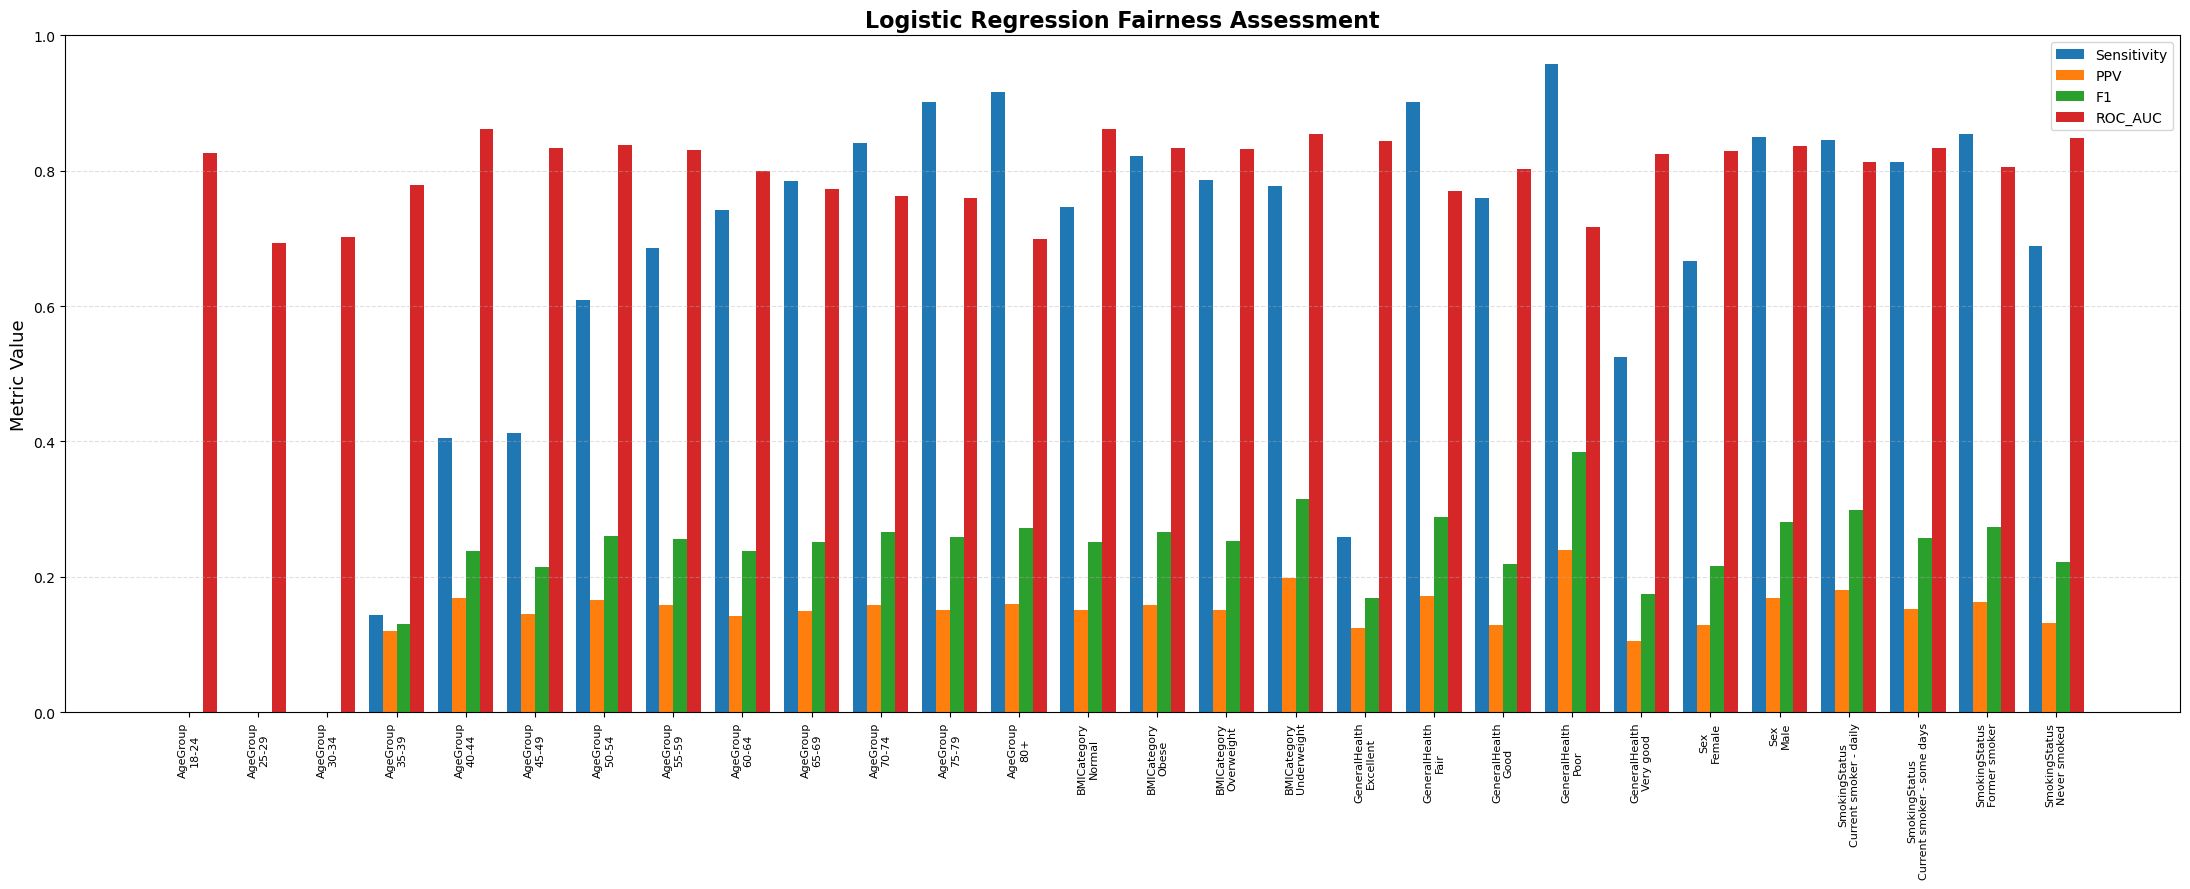

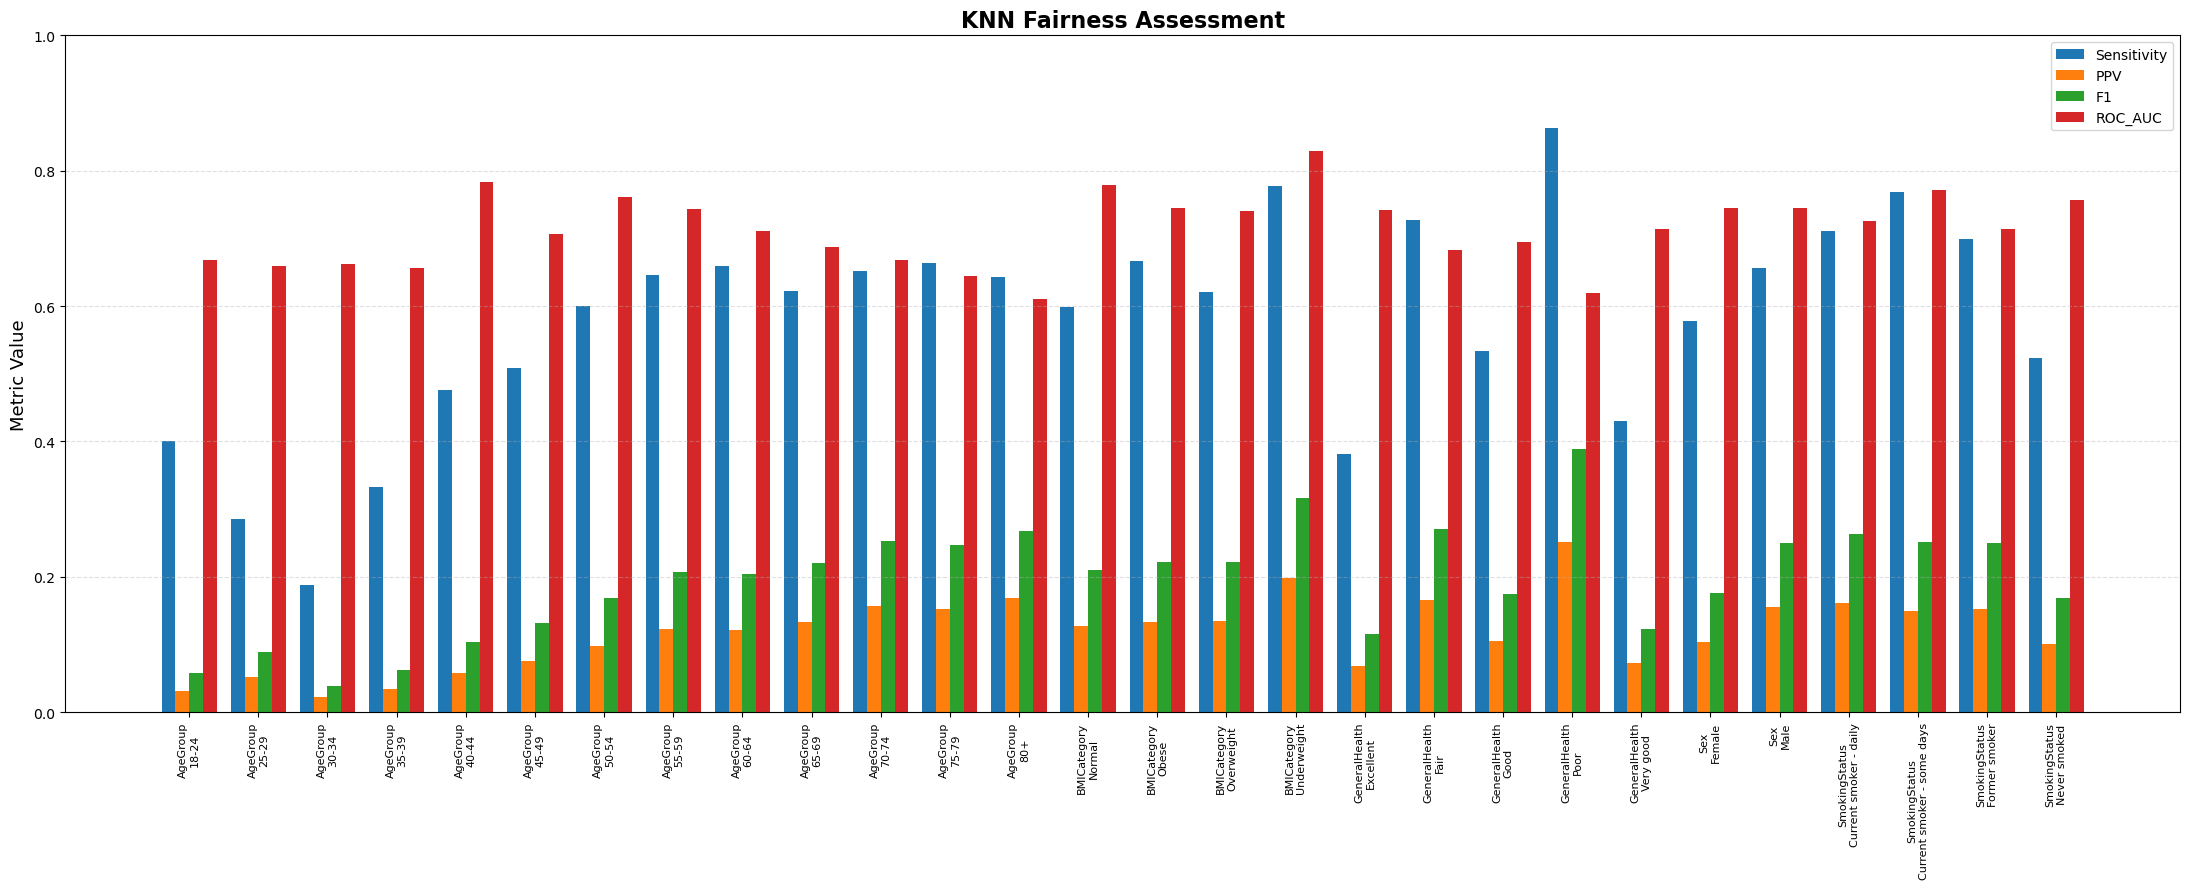

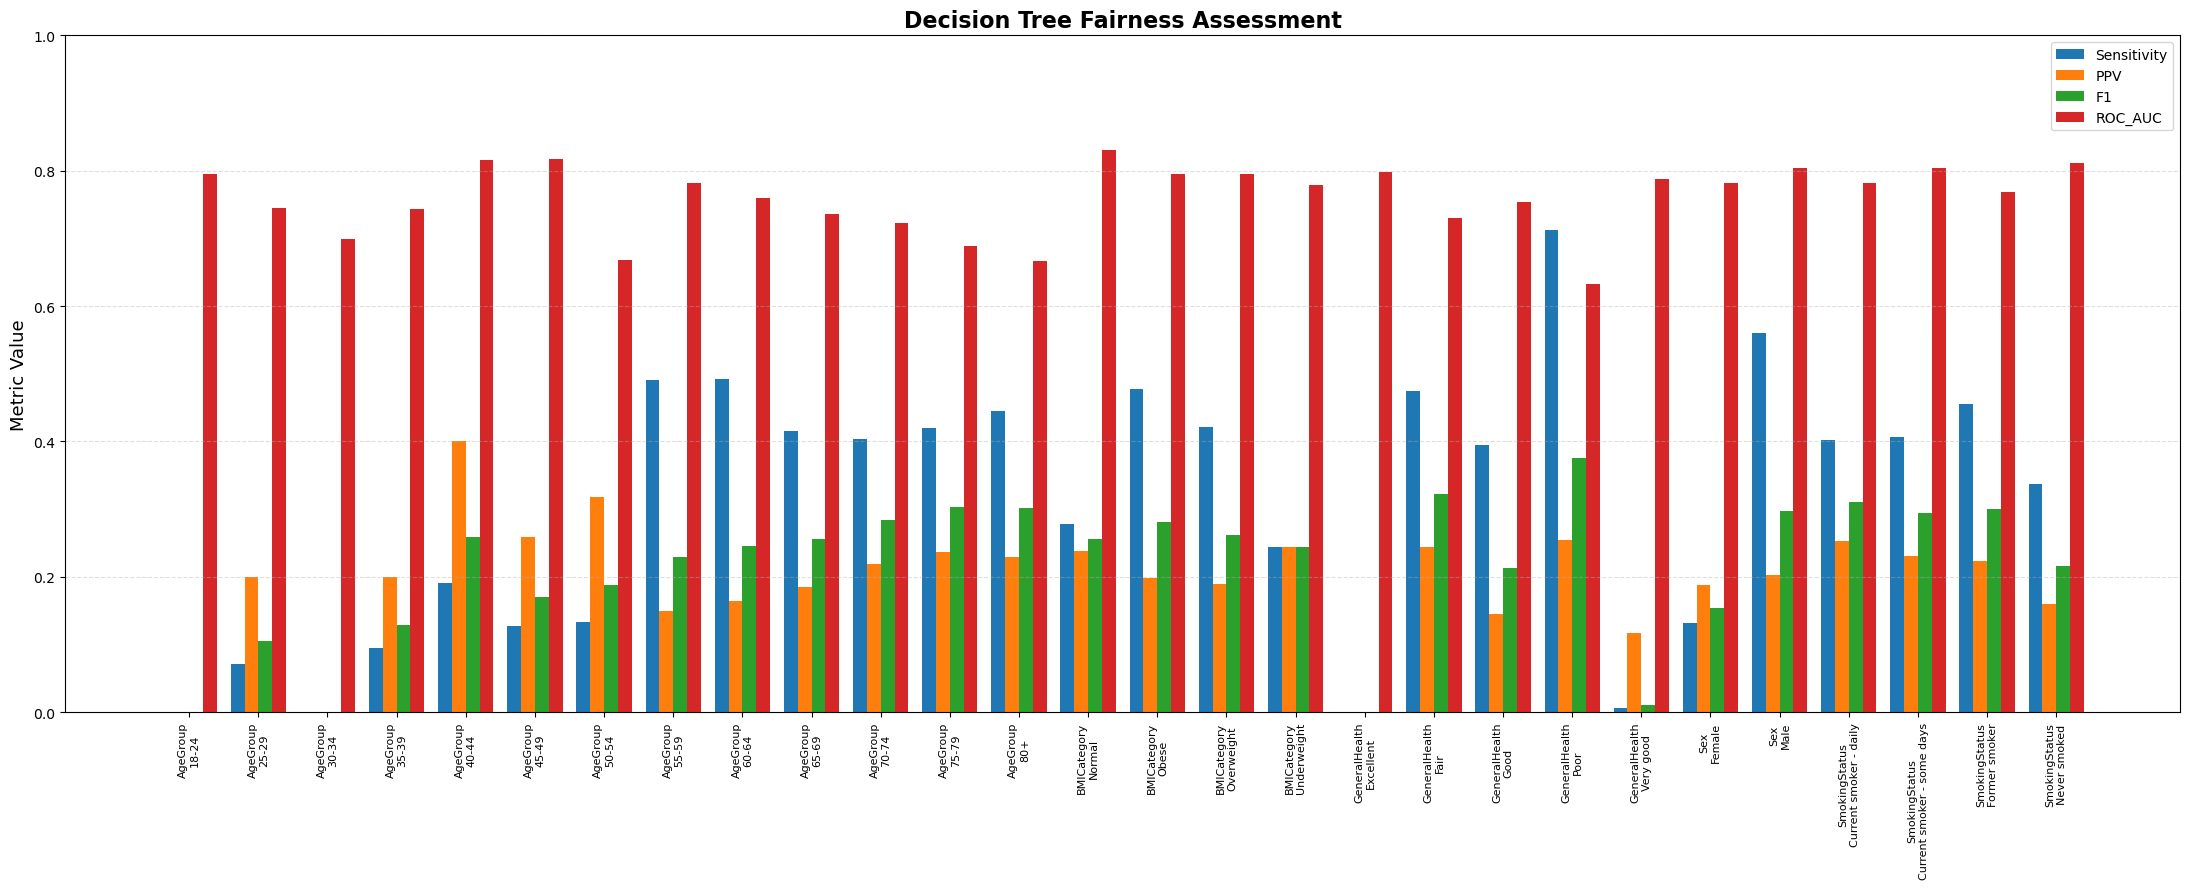

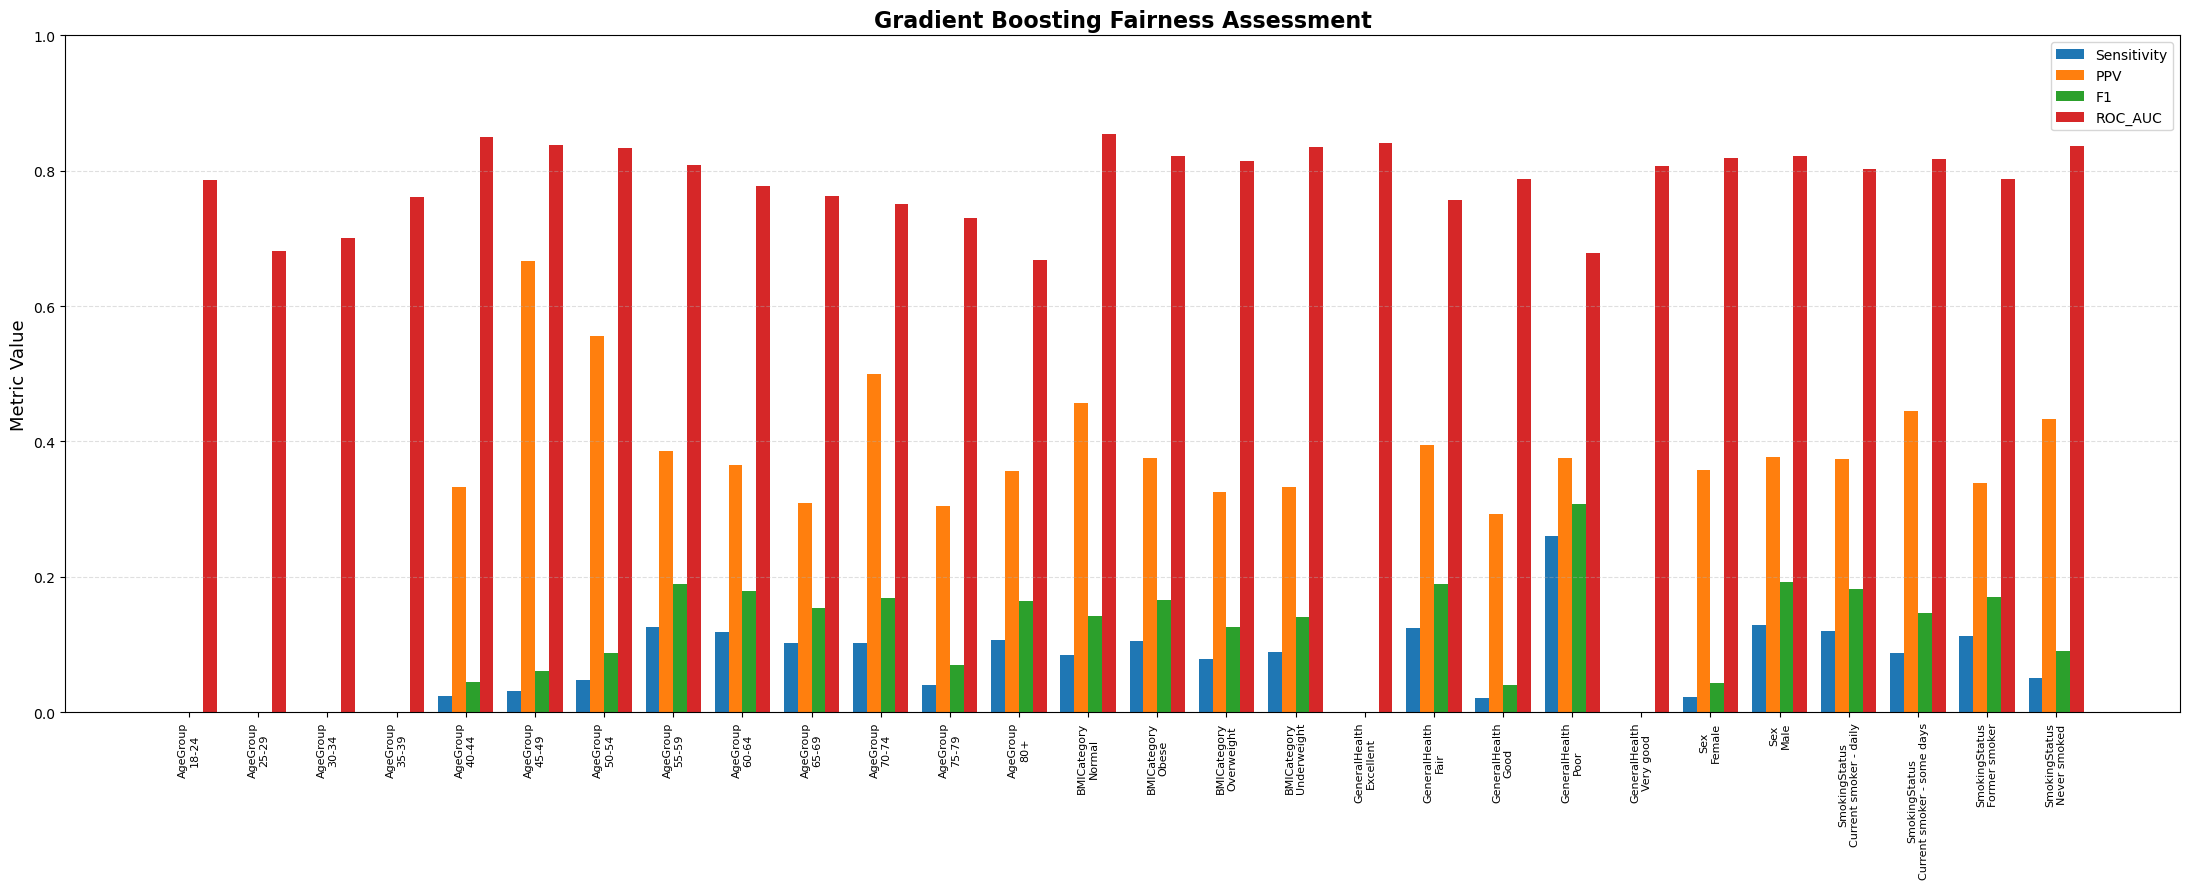

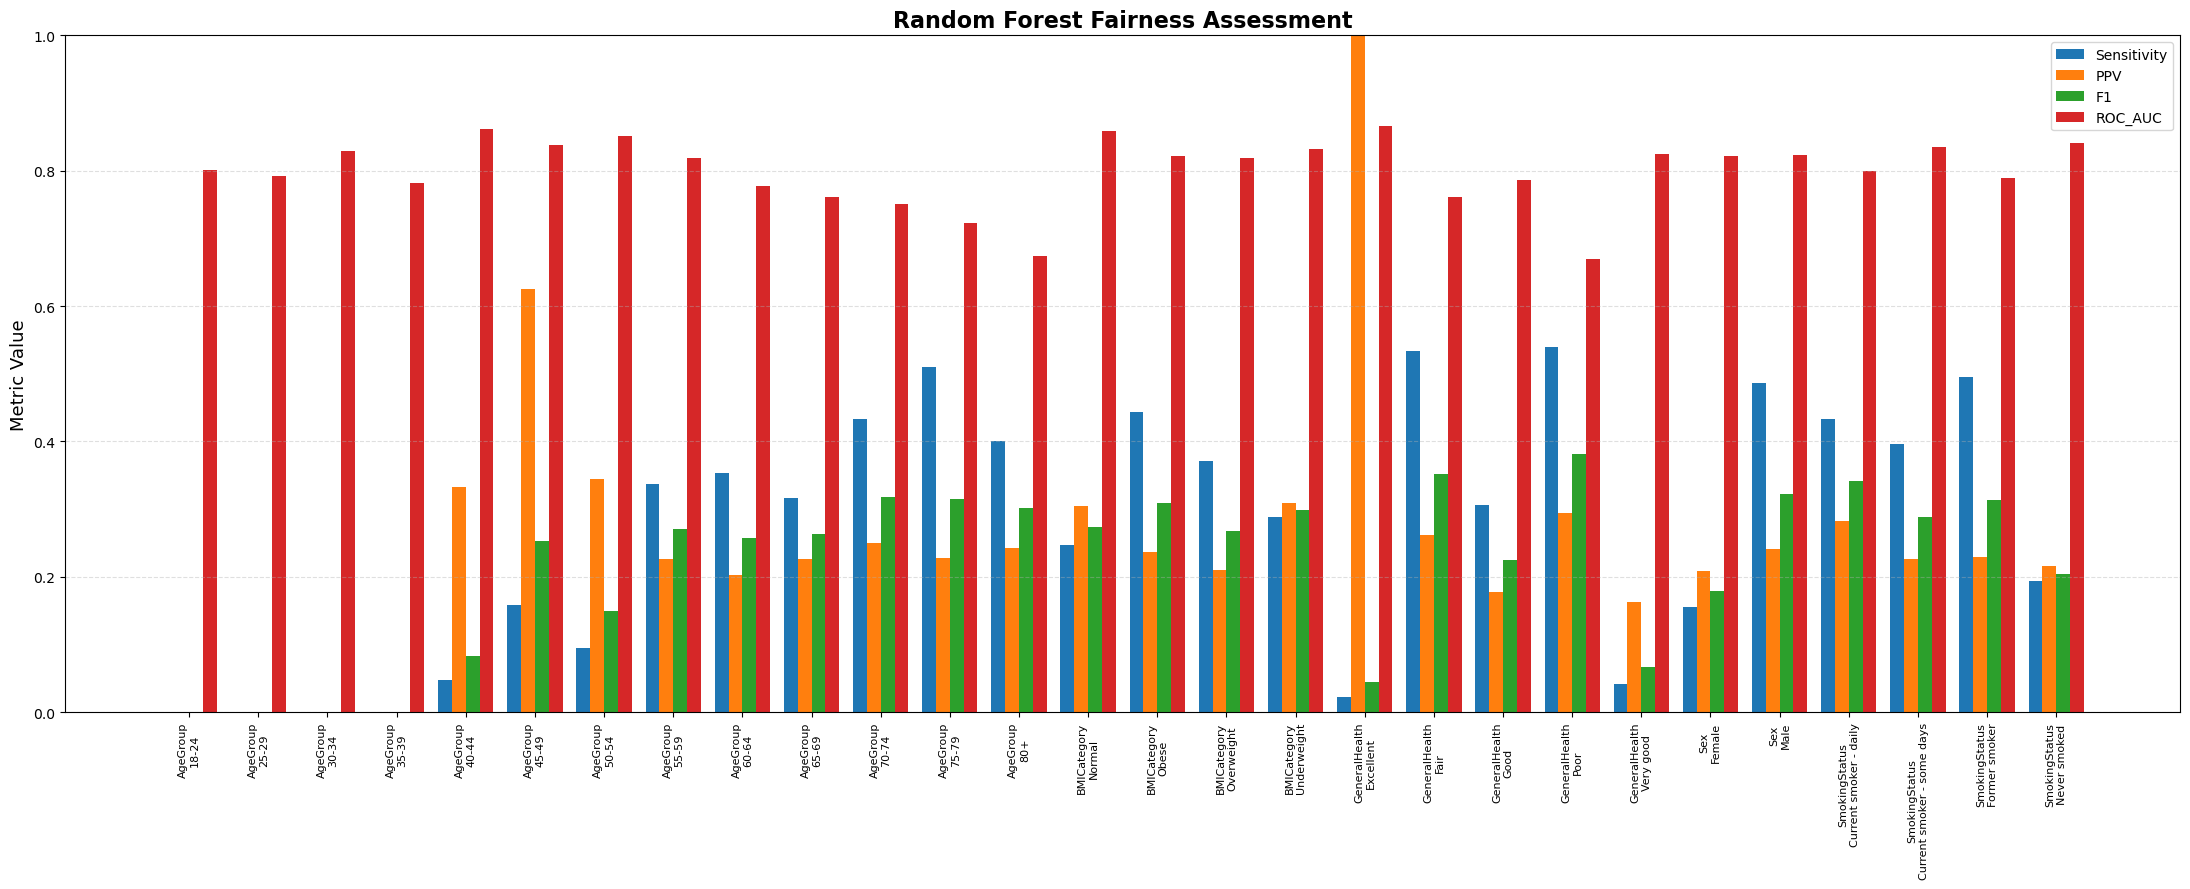

All figures saved.


In [25]:
import os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs(
    "ml_fairness_figures",
    exist_ok=True
)

METRICS = [
    "Sensitivity",
    "PPV",
    "F1",
    "ROC_AUC"
]

for model_name in ml_fairness_results["Model"].unique():

    plot_df = (
        ml_fairness_results[
            ml_fairness_results["Model"] == model_name
        ]
        .copy()
    )

    plot_df["Label"] = (
        plot_df["Feature"].astype(str)
        + "\n"
        + plot_df["Group"].astype(str)
    )

    plot_df = (
        plot_df
        .sort_values(
            ["Feature", "Group"]
        )
    )

    x = np.arange(len(plot_df))
    width = 0.20

    fig, ax = plt.subplots(
        figsize=(22, 9)
    )

    for i, metric in enumerate(METRICS):

        ax.bar(
            x + (i - 1.5) * width,
            plot_df[metric],
            width,
            label=metric
        )

    ax.set_title(
        f"{model_name} Fairness Assessment",
        fontsize=16,
        fontweight="bold"
    )

    ax.set_ylabel(
        "Metric Value",
        fontsize=13
    )

    ax.set_ylim(0, 1)

    ax.set_xticks(x)

    ax.set_xticklabels(
        plot_df["Label"],
        rotation=90,
        fontsize=8
    )

    ax.legend(fontsize=10)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        f"{model_name}_fairness.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

print("All figures saved.")